<a href="https://colab.research.google.com/github/Karthik5412/Deep-Learning-Projects/blob/main/CNN/birds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d veeralakrishna/200-bird-species-with-11788-images

Dataset URL: https://www.kaggle.com/datasets/veeralakrishna/200-bird-species-with-11788-images
License(s): CC0-1.0
100% 1.11G/1.11G [00:11<00:00, 101MB/s]



In [2]:
import zipfile

zip = zipfile.ZipFile('/content/200-bird-species-with-11788-images.zip', 'r')
zip.extractall('/content')
zip.close()

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Extract the first file (CUB_200_2011) into a specific directory
!mkdir -p bird_dataset_1
!tar -xvzf /content/CUB_200_2011.tgz -C ./bird_dataset_1

# Extract the second file (segmentations) into a specific directory
!mkdir -p bird_dataset_2
!tar -xvzf /content/segmentations.tgz -C ./bird_dataset_2

Streaming output truncated to the last 5000 lines.
segmentations/198.Rock_Wren/Rock_Wren_0125_188951.png
segmentations/198.Rock_Wren/Rock_Wren_0122_189042.png
segmentations/198.Rock_Wren/Rock_Wren_0033_189397.png
segmentations/198.Rock_Wren/Rock_Wren_0066_189034.png
segmentations/198.Rock_Wren/Rock_Wren_0114_189283.png
segmentations/198.Rock_Wren/Rock_Wren_0076_189141.png
segmentations/198.Rock_Wren/Rock_Wren_0113_189204.png
segmentations/198.Rock_Wren/Rock_Wren_0024_188942.png
segmentations/198.Rock_Wren/Rock_Wren_0069_188969.png
segmentations/198.Rock_Wren/Rock_Wren_0025_188897.png
segmentations/198.Rock_Wren/Rock_Wren_0026_189181.png
segmentations/198.Rock_Wren/Rock_Wren_0062_189045.png
segmentations/198.Rock_Wren/Rock_Wren_0109_189094.png
segmentations/198.Rock_Wren/Rock_Wren_0053_189112.png
segmentations/198.Rock_Wren/Rock_Wren_0044_189127.png
segmentations/198.Rock_Wren/Rock_Wren_0116_189101.png
segmentations/198.Rock_Wren/Rock_Wren_0111_189443.png
segmentations/198.Rock_Wren/Roc

In [ ]:
from tensorflow import  keras
from keras.utils import image_dataset_from_directory

In [ ]:
dir = '/content/bird_dataset_2/segmentations'
batch = 64

In [ ]:
train_ds = image_dataset_from_directory(directory= dir, labels= 'inferred',seed=123, subset='training', validation_split=0.2,image_size= (255,255), label_mode= 'int', batch_size= batch, color_mode='rgb')

val_ds = image_dataset_from_directory(directory= dir, labels= 'inferred', label_mode= 'int',seed=123, subset='validation', validation_split=0.2, image_size= (255,255), batch_size= batch, color_mode='rgb')

In [8]:
bird_names = train_ds.class_names
print(bird_names)

['001.Black_footed_Albatross', '002.Laysan_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird', '011.Rusty_Blackbird', '012.Yellow_headed_Blackbird', '013.Bobolink', '014.Indigo_Bunting', '015.Lazuli_Bunting', '016.Painted_Bunting', '017.Cardinal', '018.Spotted_Catbird', '019.Gray_Catbird', '020.Yellow_breasted_Chat', '021.Eastern_Towhee', '022.Chuck_will_Widow', '023.Brandt_Cormorant', '024.Red_faced_Cormorant', '025.Pelagic_Cormorant', '026.Bronzed_Cowbird', '027.Shiny_Cowbird', '028.Brown_Creeper', '029.American_Crow', '030.Fish_Crow', '031.Black_billed_Cuckoo', '032.Mangrove_Cuckoo', '033.Yellow_billed_Cuckoo', '034.Gray_crowned_Rosy_Finch', '035.Purple_Finch', '036.Northern_Flicker', '037.Acadian_Flycatcher', '038.Great_Crested_Flycatcher', '039.Least_Flycatcher', '040.Olive_sided_Flycatcher', '041.Scissor_tailed_Flycatcher', '042.Ver

In [9]:
import re

def processing_birds(bird):
    new = re.sub(r'[^a-zA-Z]+', ' ', bird)

    return new.strip()


birds =[]
for bird in bird_names :
    birds.append(processing_birds(bird))

birds

['Black footed Albatross',
 'Laysan Albatross',
 'Sooty Albatross',
 'Groove billed Ani',
 'Crested Auklet',
 'Least Auklet',
 'Parakeet Auklet',
 'Rhinoceros Auklet',
 'Brewer Blackbird',
 'Red winged Blackbird',
 'Rusty Blackbird',
 'Yellow headed Blackbird',
 'Bobolink',
 'Indigo Bunting',
 'Lazuli Bunting',
 'Painted Bunting',
 'Cardinal',
 'Spotted Catbird',
 'Gray Catbird',
 'Yellow breasted Chat',
 'Eastern Towhee',
 'Chuck will Widow',
 'Brandt Cormorant',
 'Red faced Cormorant',
 'Pelagic Cormorant',
 'Bronzed Cowbird',
 'Shiny Cowbird',
 'Brown Creeper',
 'American Crow',
 'Fish Crow',
 'Black billed Cuckoo',
 'Mangrove Cuckoo',
 'Yellow billed Cuckoo',
 'Gray crowned Rosy Finch',
 'Purple Finch',
 'Northern Flicker',
 'Acadian Flycatcher',
 'Great Crested Flycatcher',
 'Least Flycatcher',
 'Olive sided Flycatcher',
 'Scissor tailed Flycatcher',
 'Vermilion Flycatcher',
 'Yellow bellied Flycatcher',
 'Frigatebird',
 'Northern Fulmar',
 'Gadwall',
 'American Goldfinch',
 'Euro

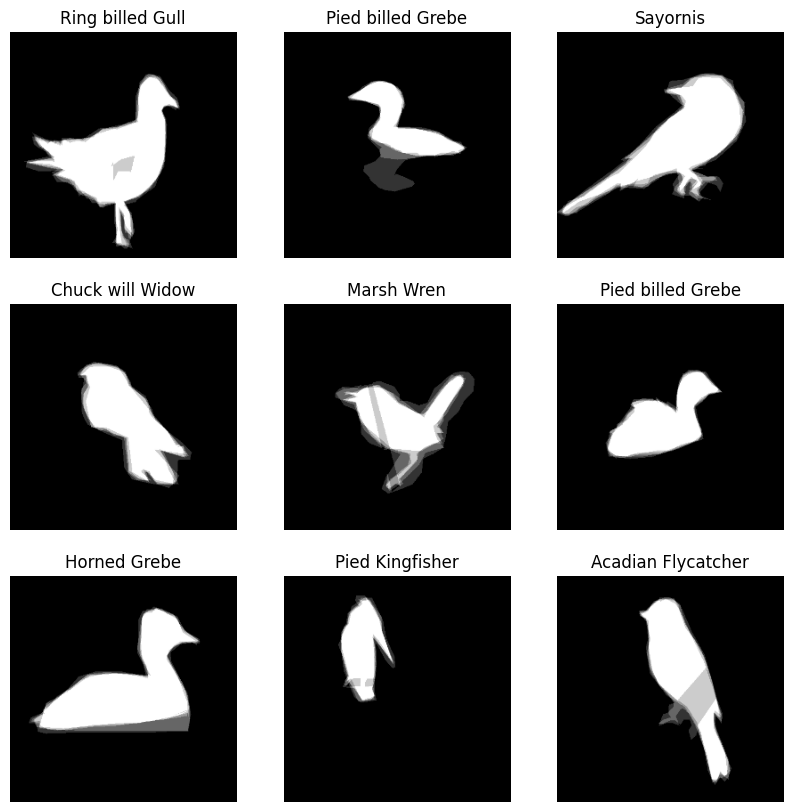

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize= (10,10))
for image , labels in train_ds.take(1):
    for i in range(9) :
        plt.subplot(3,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(birds[labels[i]])
        plt.axis('off')

In [11]:
import tensorflow as tf

def scale(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(scale)
val_ds = val_ds.map(scale)

In [12]:
import pandas as pd
import numpy as np

In [20]:
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from keras import Sequential

In [22]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3),padding='valid', activation='relu',input_shape=(255,255,3)),
    MaxPool2D(pool_size=(3,3),strides=2),
    Conv2D(64, kernel_size=(3,3),padding='valid', activation='relu'),
    MaxPool2D(pool_size=(3,3),strides=2),
    Conv2D(128, kernel_size=(3,3),padding='valid', activation='relu'),
    MaxPool2D(pool_size=(3,3),strides=2),
    Conv2D(256, kernel_size=(3,3),padding='valid', activation='relu'),
    MaxPool2D(pool_size=(3,3),strides=2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(200,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 253, 253, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        13,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,947,592 (22.69 MB)

 Trainable params: 5,947,592 (22.69 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [25]:
history = cnn.fit(train_ds,validation_data=val_ds, epochs= 15, validation_split=0.2, batch_size=32,verbose=1)

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 189ms/step - accuracy: 0.0037 - loss: 5.3003 - val_accuracy: 0.0042 - val_loss: 5.2994
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 165ms/step - accuracy: 0.0042 - loss: 5.2987 - val_accuracy: 0.0017 - val_loss: 5.3007
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.0046 - loss: 5.2982 - val_accuracy: 0.0017 - val_loss: 5.3016
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step - accuracy: 0.0053 - loss: 5.2978 - val_accuracy: 0.0017 - val_loss: 5.3027
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 154ms/step - accuracy: 0.0056 - loss: 5.2976 - val_accuracy: 0.0017 - val_loss: 5.3037
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - accuracy: 0.0058 - loss: 5.2974 - val_accuracy: 0.0017 - val_loss: 5.3044
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.0056 - loss: 5.2972 - val_accuracy: 0.0017 - val_loss: 5.3051
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - accuracy: 0.0055 - loss: 5